# Predicción de Churn (baja de clientes) — Telco Customer Churn

**Materia:** Taller de Lenguajes de Programación III — Python para Ciencia de Datos

## 1. El problema de negocio

Una empresa de telecomunicaciones pierde clientes todos los meses (*churn* = baja).
Conseguir un cliente nuevo cuesta entre 5 y 7 veces más que retener uno existente,
por eso a la empresa le conviene **detectar a tiempo** qué clientes tienen alta
probabilidad de darse de baja, para ofrecerles descuentos o mejoras antes de que se vayan.

**Objetivo:** entrenar un modelo de Machine Learning que, a partir de los datos de un
cliente (tipo de contrato, antigüedad, servicios contratados, facturación), prediga si
se va a dar de baja o no. Es un problema de **clasificación binaria supervisada**.

## 2. El dataset

- **Fuente:** Telco Customer Churn (IBM), publicado en Kaggle.
- **Tamaño:** 7.043 filas × 21 columnas (cumple el mínimo de 500 filas y 6 columnas).
- **Target:** la columna `Churn` (Yes/No).

In [1]:
# Librerías que vamos a usar en todo el notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

sns.set_theme(style="whitegrid")
RUTA_CSV = Path("dataset-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 3. Carga de datos y primer vistazo

In [2]:
df = pd.read_csv(RUTA_CSV)
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 7043  |  Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Tipos de datos y valores no nulos de cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observación importante:** `TotalCharges` figura como `object` (texto) cuando debería
ser numérica. Eso es un problema de calidad de datos que vamos a resolver en el
preprocesamiento. El resto: 4 variables numéricas y el resto categóricas.

In [4]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 ¿Qué tan desbalanceado está el target?

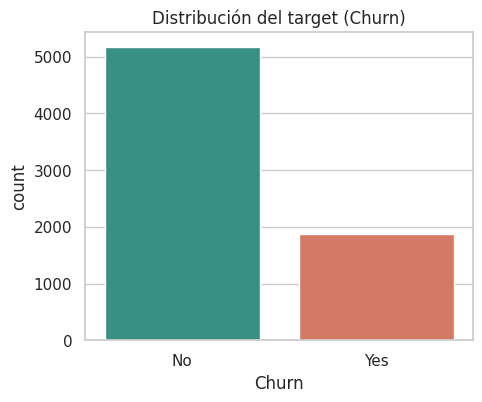

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de churn: 26.5%


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Churn", hue="Churn", palette=["#2a9d8f", "#e76f51"], legend=False, ax=ax)
ax.set_title("Distribución del target (Churn)")
plt.show()

print(df["Churn"].value_counts())
print(f"\nPorcentaje de churn: {df['Churn'].eq('Yes').mean()*100:.1f}%")

Solo ~26,5% de los clientes se da de baja: las **clases están desbalanceadas**.
Esto condiciona dos decisiones posteriores:

1. Usar `class_weight='balanced'` en el modelo, para que no aprenda a decir siempre "No".
2. No quedarnos solo con accuracy: mirar también **recall, F1 y ROC AUC**.

### 4.2 ¿Qué variables se relacionan con el churn?

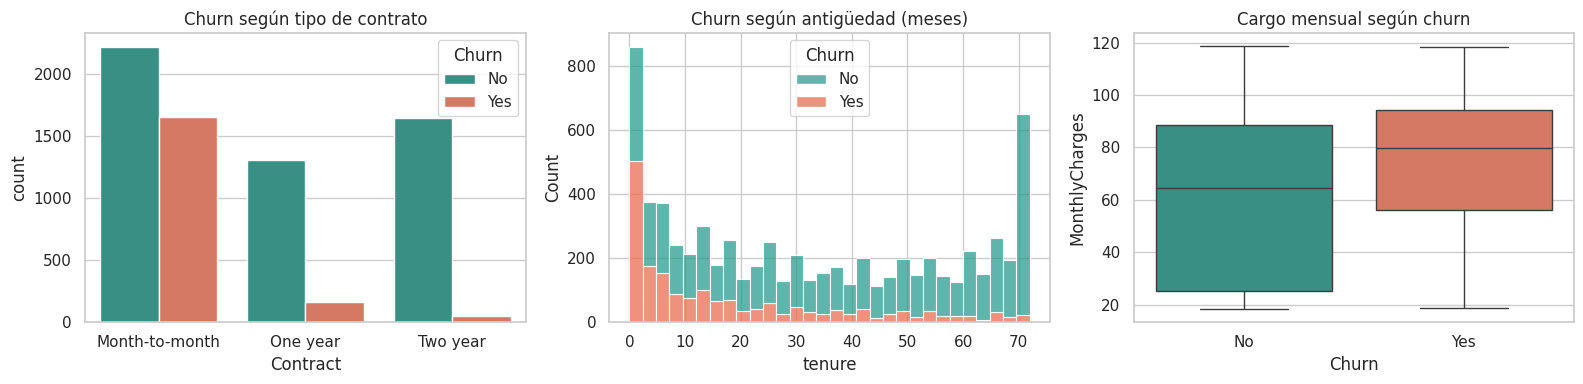

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Tipo de contrato: hipótesis -> contrato mes a mes = más fácil irse
sns.countplot(data=df, x="Contract", hue="Churn", palette=["#2a9d8f", "#e76f51"], ax=axes[0])
axes[0].set_title("Churn según tipo de contrato")

# Antigüedad: hipótesis -> clientes nuevos se van más
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack",
             palette=["#2a9d8f", "#e76f51"], bins=30, ax=axes[1])
axes[1].set_title("Churn según antigüedad (meses)")

# Cargo mensual: hipótesis -> los que pagan más se van más
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn",
            palette=["#2a9d8f", "#e76f51"], legend=False, ax=axes[2])
axes[2].set_title("Cargo mensual según churn")

plt.tight_layout()
plt.show()

**Tendencias claras que encontramos:**

- **Contrato:** el churn se concentra casi por completo en contratos *month-to-month*.
- **Antigüedad:** los clientes que se van son mayormente **nuevos** (pocos meses de tenure).
- **Cargo mensual:** los que se dan de baja pagan, en mediana, **más** por mes.

Estas tres variables van a ser de las más importantes para el modelo.

### 4.3 Correlaciones entre variables numéricas

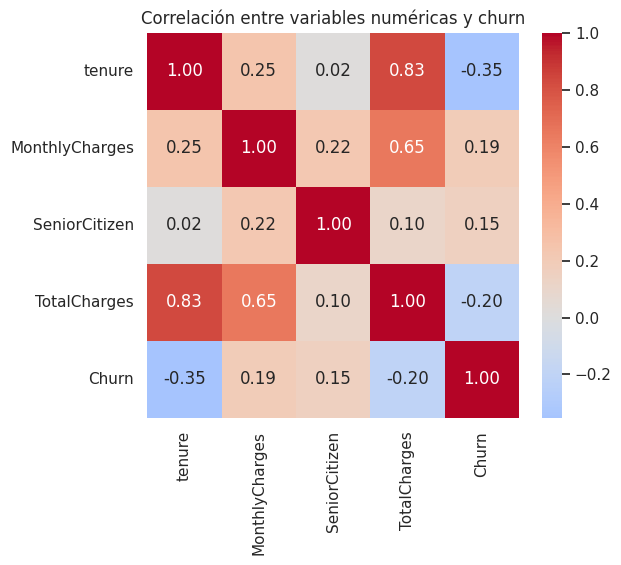

In [7]:
# Convertimos TotalCharges a número solo para la matriz de correlación
numericas = df[["tenure", "MonthlyCharges", "SeniorCitizen"]].copy()
numericas["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
numericas["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(numericas.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre variables numéricas y churn")
plt.show()

**Lectura del heatmap:**

- `tenure` y `TotalCharges` están muy correlacionadas (0,83): lógico, cuanto más tiempo
  sos cliente, más pagaste en total acumulado.
- `tenure` tiene correlación **negativa** con churn (−0,35): más antigüedad → menos baja.
- `MonthlyCharges` correlaciona positivo con churn: pagar más por mes → más baja.

## 5. Preprocesamiento

### 5.1 Limpieza de valores nulos y tipos

In [8]:
# customerID es solo un identificador: no aporta información predictiva
df = df.drop(columns=["customerID"])

# TotalCharges viene como texto y tiene celdas en blanco -> a número (los blancos quedan NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"Nulos en TotalCharges: {df['TotalCharges'].isna().sum()}")

# Son los clientes con tenure=0 (recién ingresados, todavía no facturaron)
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]]

Nulos en TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


Son solo **11 nulos** (clientes con `tenure = 0` que aún no facturaron). En lugar de
borrar esas filas, los vamos a **imputar con la mediana** dentro del pipeline
(`SimpleImputer`). Así, si en producción llega un dato faltante, el modelo no se rompe.

### 5.2 Tratamiento de outliers (datos atípicos)

tenure          -> rango válido [   -60.0,    124.0] | outliers: 0
MonthlyCharges  -> rango válido [   -46.0,    171.4] | outliers: 0
TotalCharges    -> rango válido [ -4688.5,   8884.7] | outliers: 0


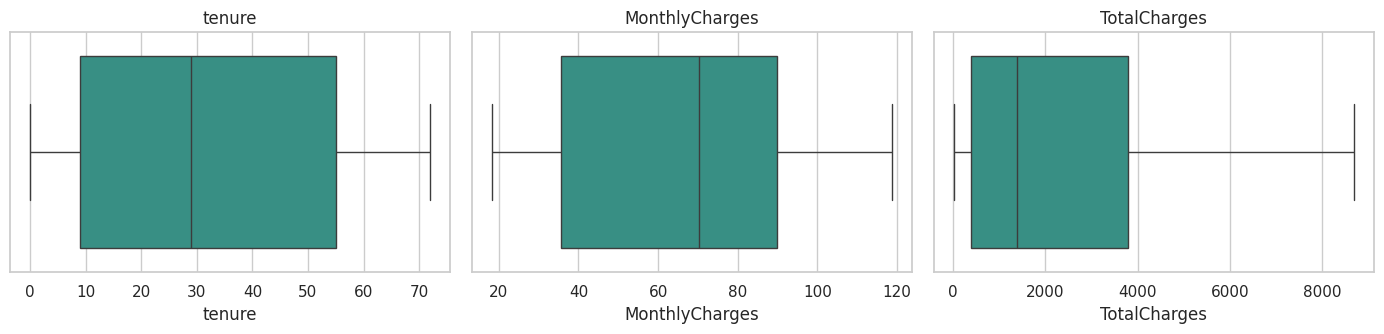

In [9]:
# Detección de outliers con el criterio del rango intercuartílico (IQR)
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)]
    print(f"{col:15s} -> rango válido [{limite_inf:8.1f}, {limite_sup:8.1f}] | outliers: {len(outliers)}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(x=df[col], color="#2a9d8f", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Decisión justificada:** el criterio IQR no detecta outliers en ninguna de las tres
variables (los boxplots no muestran puntos fuera de los bigotes). Son valores reales de
facturación y antigüedad, dentro de rangos comerciales lógicos. Por lo tanto **no
eliminamos ni recortamos filas**. Igualmente el modelo elegido (Random Forest) es
robusto a outliers porque trabaja con cortes por umbral, no con distancias.

### 5.3 Target a 0/1 y separación de variables

In [10]:
# Target: Yes/No -> 1/0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop(columns=["Churn"])
y = df["Churn"]

columnas_numericas = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
columnas_categoricas = [c for c in X.columns if c not in columnas_numericas]

print(f"Numéricas  ({len(columnas_numericas)}): {columnas_numericas}")
print(f"Categóricas ({len(columnas_categoricas)}): {columnas_categoricas}")

Numéricas  (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 5.4 Pipeline de transformación (imputación + estandarización + one-hot)

Todo el preprocesamiento va **adentro de un Pipeline de scikit-learn**:

- **Numéricas:** `SimpleImputer(median)` rellena nulos + `StandardScaler` estandariza
  (media 0, desvío 1) para que todas queden en la misma escala.
- **Categóricas:** `OneHotEncoder` convierte cada categoría en una columna 0/1.
  `handle_unknown='ignore'` evita que la API explote si llega una categoría nueva.

**¿Por qué un Pipeline?** Porque al exportarlo con joblib se guarda **el preprocesamiento
y el modelo juntos**: la API recibe datos crudos y el pipeline los transforma exactamente
igual que en el entrenamiento. Además evita *data leakage*: el scaler y el imputer se
ajustan solo con los datos de entrenamiento.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

preproceso_num = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),   # nulos -> mediana
    ("escalador", StandardScaler()),                   # estandarización
])

preproceso_cat = OneHotEncoder(handle_unknown="ignore")

preprocesador = ColumnTransformer(transformers=[
    ("num", preproceso_num, columnas_numericas),
    ("cat", preproceso_cat, columnas_categoricas),
])

## 6. Modelado

### 6.1 División train/test

In [12]:
from sklearn.model_selection import train_test_split

# stratify=y mantiene la misma proporción de churn (26,5%) en train y en test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} filas | Test: {len(X_test)} filas")

Train: 5634 filas | Test: 1409 filas


### 6.2 Selección del modelo: comparamos dos candidatos

Entrenamos dos algoritmos y elegimos con métricas, no a ojo:

- **Regresión Logística:** modelo lineal, simple e interpretable. Es la línea base.
- **Random Forest:** ensamble de muchos árboles de decisión entrenados sobre muestras
  aleatorias; promedia sus votos. Captura relaciones **no lineales** e interacciones
  entre variables sin que tengamos que especificarlas.

En ambos usamos `class_weight='balanced'` por el desbalance de clases.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score

candidatos = {
    "Regresión Logística": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    ),
}

resultados = {}
for nombre, clf in candidatos.items():
    pipe = Pipeline(steps=[("preprocesador", preprocesador), ("modelo", clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    resultados[nombre] = {
        "accuracy": accuracy_score(y_test, pred),
        "recall_churn": recall_score(y_test, pred),
        "f1_churn": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "pipeline": pipe,
    }

pd.DataFrame(resultados).T.drop(columns="pipeline").round(3)

,accuracy,recall_churn,f1_churn,roc_auc
Regresión Logística,0.738112,0.783422,0.613613,0.841298
Random Forest,0.780696,0.481283,0.538117,0.820809


Ambos modelos rinden parecido en ROC AUC. Elegimos **Random Forest** como modelo final:

1. Captura interacciones no lineales (ej.: "contrato mensual **y además** fibra óptica").
2. Es robusto a outliers y no exige supuestos sobre la distribución de los datos.
3. Nos da `feature_importances_` para explicar qué variables pesan más.

### 6.3 Evaluación detallada del modelo final

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay

pipeline_final = resultados["Random Forest"]["pipeline"]
y_pred = pipeline_final.predict(X_test)
y_proba = pipeline_final.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

              precision    recall  f1-score   support

    No churn       0.83      0.89      0.86      1035
       Churn       0.61      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



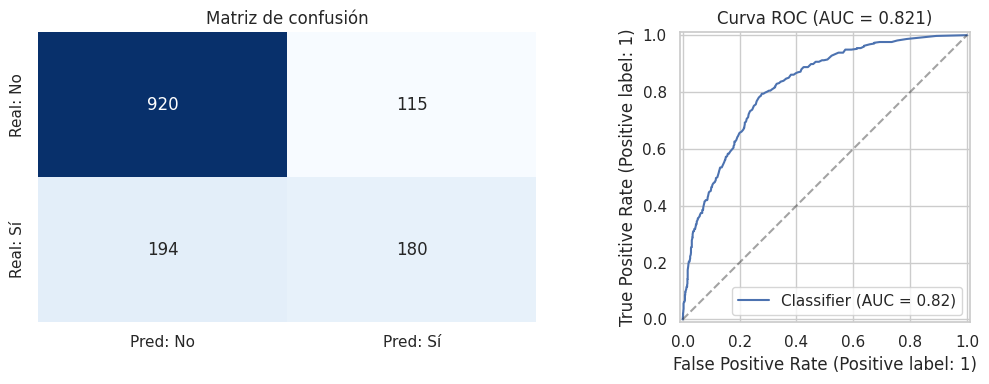

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred: No", "Pred: Sí"],
            yticklabels=["Real: No", "Real: Sí"], ax=axes[0])
axes[0].set_title("Matriz de confusión")

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title(f"Curva ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})")

plt.tight_layout()
plt.show()

**Cómo leer la matriz de confusión:** las filas son la realidad y las columnas la
predicción. Los errores que más le duelen al negocio son los **falsos negativos**
(clientes que se fueron y el modelo dijo que se quedaban), porque son bajas que nadie
intentó retener.

### 6.4 ¿Qué variables pesan más en la predicción?

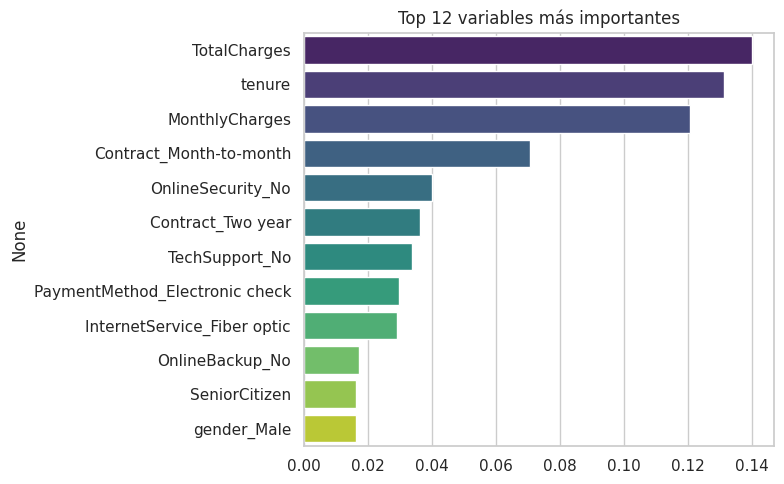

In [16]:
# Importancia de variables del Random Forest
ohe = pipeline_final.named_steps["preprocesador"].named_transformers_["cat"]
nombres = columnas_numericas + list(ohe.get_feature_names_out(columnas_categoricas))
importancias = pd.Series(
    pipeline_final.named_steps["modelo"].feature_importances_, index=nombres
).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index,
            palette="viridis", legend=False, ax=ax)
ax.set_title("Top 12 variables más importantes")
plt.tight_layout()
plt.show()

Coincide con lo que vimos en el EDA: **TotalCharges, tenure, MonthlyCharges y el tipo
de contrato** dominan la predicción. El modelo es coherente con el análisis exploratorio.

## 7. Exportación del modelo

Guardamos el **pipeline completo** (preprocesamiento + modelo) con `joblib` en
`models/modelo.pkl`, y las métricas en `models/metricas.json` para que la interfaz
web pueda mostrar cómo rinde el modelo.

In [17]:
import json

Path("models").mkdir(exist_ok=True)
# compress=3 reduce el archivo de ~41 MB a ~3 MB (mas liviano para el repo)
joblib.dump(pipeline_final, "models/modelo.pkl", compress=3)

metricas = {
    "modelo": "Random Forest (200 árboles, class_weight=balanced)",
    "registros_entrenamiento": len(X_train),
    "registros_test": len(X_test),
    "accuracy": round(accuracy_score(y_test, y_pred), 4),
    "recall_churn": round(recall_score(y_test, y_pred), 4),
    "f1_churn": round(f1_score(y_test, y_pred), 4),
    "roc_auc": round(roc_auc_score(y_test, y_proba), 4),
    "matriz_confusion": cm.tolist(),
}
with open("models/metricas.json", "w", encoding="utf-8") as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

print("Exportado: models/modelo.pkl y models/metricas.json")
metricas

Exportado: models/modelo.pkl y models/metricas.json


{'modelo': 'Random Forest (200 árboles, class_weight=balanced)',
 'registros_entrenamiento': 5634,
 'registros_test': 1409,
 'accuracy': 0.7807,
 'recall_churn': 0.4813,
 'f1_churn': 0.5381,
 'roc_auc': 0.8208,
 'matriz_confusion': [[920, 115], [194, 180]]}

## 8. Conclusiones

- El churn se concentra en clientes **nuevos, con contrato mes a mes y cargos mensuales altos**.
- El pipeline final (imputación + estandarización + one-hot + Random Forest) alcanza un
  **ROC AUC ≈ 0,82** sobre datos que nunca vio.
- El modelo exportado en `models/modelo.pkl` lo consume la API de FastAPI (`main.py`),
  y la interfaz `index.html` permite cargar un cliente y ver la predicción y las métricas.

**Mejoras posibles:** ajustar hiperparámetros con `GridSearchCV`, probar Gradient
Boosting (XGBoost/LightGBM), y ajustar el umbral de decisión para priorizar recall.